## Importer les librairies necessaires

In [10]:
# Data manipulation
import numpy as np
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Missing data imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Categorical data encoding
from sklearn.preprocessing import LabelEncoder

# Train-test split and k-fold cross validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Resampling
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Classification algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn import metrics
from sklearn.metrics import f1_score

# Warning suppression
import warnings
warnings.filterwarnings('ignore')

## Chargement et Exploration des donnees

In [11]:
import os

# Trouve le dossier racine du projet en remontant depuis le dossier courant jusqu'à ce qu'on trouve 'data'
def find_project_root(current_path, target_folder="data"):
    path = current_path
    while True:
        if target_folder in os.listdir(path):
            return path
        new_path = os.path.dirname(path)
        if new_path == path:  # On est arrivé à la racine du disque sans trouver
            raise FileNotFoundError(f"Le dossier '{target_folder}' n'a pas été trouvé dans la hiérarchie des dossiers.")
        path = new_path

# Récupère le dossier courant
current_dir = os.getcwd()

# Trouve la racine du projet (dossier qui contient 'data')
project_root = find_project_root(current_dir, target_folder="data")

# Construit le chemin vers le dossier data/processed
data_processed_dir = os.path.join(project_root, "data", "processed")

# Chemin complet vers le fichier CSV
csv_path = os.path.join(data_processed_dir, "accidents_clean.csv")

print("Chemin absolu vers le fichier :", csv_path)

# Chargement du fichier
import pandas as pd
df = pd.read_csv(csv_path)
print(df.head())


Chemin absolu vers le fichier : /Users/alizeeblanchon/Documents/Data_Scientist/data_project/mai25_bds_accidents/data/processed/accidents_clean.csv
   obs  obsm  choc  manv  motor  place  catu  grav  sexe  trajet  ...  circ  \
0  0.0   2.0   5.0    23      1    2.0     2     2     2     0.0  ...   3.0   
1  0.0   2.0   5.0    23      1    1.0     1     2     2     5.0  ...   3.0   
2  1.0   0.0   3.0    11      1    1.0     1     1     1     0.0  ...   3.0   
3  4.0   0.0   1.0     0      1    1.0     1     2     2     0.0  ...   1.0   
4  0.0   2.0   1.0     2      1    1.0     1     1     1     0.0  ...   3.0   

   prof  plan surf  infra situ vma   age  equipements  catv_regroup  
0   1.0   2.0  1.0    2.0  1.0  70  17.0   [1.0, 0.0]           5.0  
1   1.0   2.0  1.0    2.0  1.0  70  26.0   [1.0, 0.0]           5.0  
2   1.0   2.0  1.0    2.0  1.0  70  60.0   [1.0, 0.0]           6.0  
3   4.0   2.0  1.0    0.0  1.0  70  25.0   [1.0, 0.0]           5.0  
4   1.0   3.0  1.0    0.0  1

In [12]:
# Fonction pour séparer les variables explicatives (X) et la variable cible (y)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Séparation X / y
X = df.drop('grav', axis=1)
y = df['grav']

# Encodage des variables catégorielles
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])


# Découpage en train / test / validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=0
)

# Normaliser les variables

scaler = StandardScaler()

# Apprentissage du scaler sur le train
X_train_scaled = scaler.fit_transform(X_train)

# Application du même scaler sur le test
X_valid_scaled = scaler.transform(X_valid)

In [13]:
import numpy as np
print("NaN dans X_train_scaled :", np.isnan(X_train_scaled).sum())
print("NaN dans X_valid_scaled :", np.isnan(X_valid_scaled).sum())

NaN dans X_train_scaled : 0
NaN dans X_valid_scaled : 0


## Entrainement et evaluation des modeles de classification

### RandomForestClassifier

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialisation du modèle
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=0
)

# Entraînement
rf_model.fit(X_train, y_train)

# Prédiction
y_pred = rf_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Random Forest :")
print(classification_report(y_valid, y_pred))


Rapport de classification - Random Forest :
              precision    recall  f1-score   support

           1       0.75      0.85      0.80     27822
           2       0.70      0.69      0.69     26242
           3       0.57      0.45      0.50      9984
           4       0.51      0.10      0.16      1693

    accuracy                           0.71     65741
   macro avg       0.63      0.52      0.54     65741
weighted avg       0.70      0.71      0.69     65741



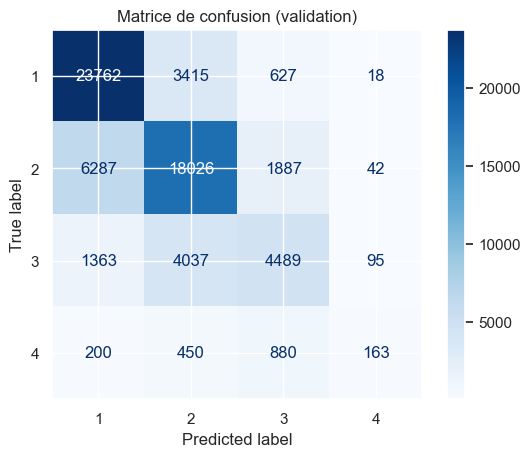

In [15]:
# Matrice de confusion
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion (validation)")
plt.show()

### Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=0
)

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_valid_scaled)

print("Rapport de classification - Logistic Regression :")
print(classification_report(y_valid, y_pred_log))

Rapport de classification - Logistic Regression :
              precision    recall  f1-score   support

           1       0.70      0.74      0.72     27822
           2       0.65      0.40      0.50     26242
           3       0.32      0.29      0.31      9984
           4       0.08      0.54      0.15      1693

    accuracy                           0.53     65741
   macro avg       0.44      0.49      0.42     65741
weighted avg       0.60      0.53      0.55     65741



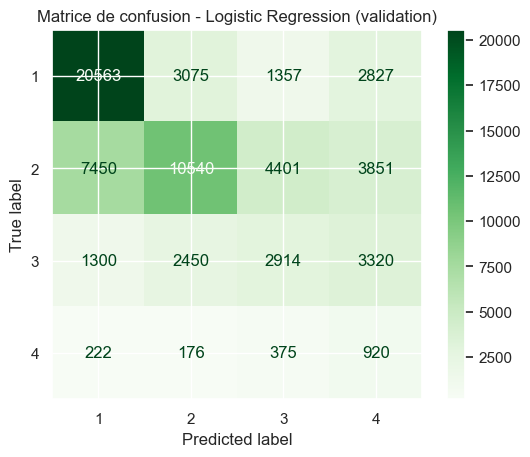

In [17]:
#  Matrice de confusion
cm_log = confusion_matrix(y_valid, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_model.classes_)
disp.plot(cmap='Greens')
plt.title("Matrice de confusion - Logistic Regression (validation)")
plt.show()

### AdaBoostClassifier

In [18]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=0
)

# Entraînement du modèle
ada_model.fit(X_train, y_train)

# Prédictions
y_pred_ada = ada_model.predict(X_valid)

# Évaluation
print("Rapport de classification - AdaBoost :")
print(classification_report(y_valid, y_pred_ada))


Rapport de classification - AdaBoost :
              precision    recall  f1-score   support

           1       0.66      0.74      0.70     27822
           2       0.57      0.62      0.59     26242
           3       0.49      0.29      0.37      9984
           4       0.38      0.01      0.01      1693

    accuracy                           0.60     65741
   macro avg       0.52      0.41      0.42     65741
weighted avg       0.59      0.60      0.59     65741



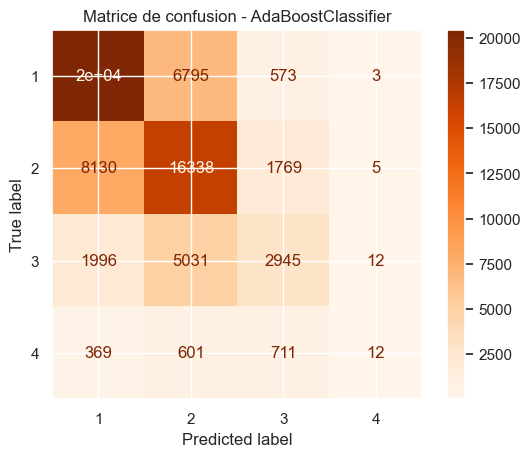

In [19]:
cm_ada = confusion_matrix(y_valid, y_pred_ada)
ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=ada_model.classes_).plot(cmap='Oranges')
plt.title("Matrice de confusion - AdaBoostClassifier")
plt.show()

### DecisionTreeClassifier

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
tree_model = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=None,           
    class_weight='balanced',  
    random_state=0
)

# Entraînement
tree_model.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Decision Tree :")
print(classification_report(y_valid, y_pred_tree))

Rapport de classification - Decision Tree :
              precision    recall  f1-score   support

           1       0.72      0.71      0.71     27822
           2       0.60      0.60      0.60     26242
           3       0.41      0.41      0.41      9984
           4       0.19      0.20      0.19      1693

    accuracy                           0.61     65741
   macro avg       0.48      0.48      0.48     65741
weighted avg       0.61      0.61      0.61     65741



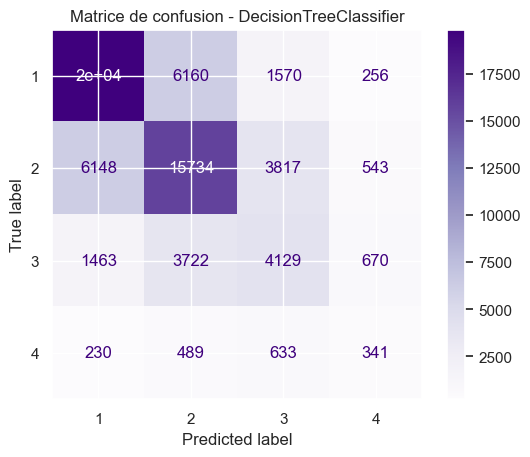

In [21]:
cm_tree = confusion_matrix(y_valid, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=tree_model.classes_).plot(cmap='Purples')
plt.title("Matrice de confusion - DecisionTreeClassifier")
plt.show()

### ExtraTreesClassifier

In [22]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
et_model = ExtraTreesClassifier(
    n_estimators=100,         
    max_depth=None,           
    class_weight='balanced',  
    random_state=0,
    n_jobs=-1                 
)

# Entraînement
et_model.fit(X_train, y_train)

# Prédictions
y_pred_et = et_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Extra Trees :")
print(classification_report(y_valid, y_pred_et))

Rapport de classification - Extra Trees :
              precision    recall  f1-score   support

           1       0.75      0.85      0.80     27822
           2       0.68      0.69      0.69     26242
           3       0.57      0.43      0.49      9984
           4       0.51      0.09      0.15      1693

    accuracy                           0.70     65741
   macro avg       0.63      0.51      0.53     65741
weighted avg       0.69      0.70      0.69     65741



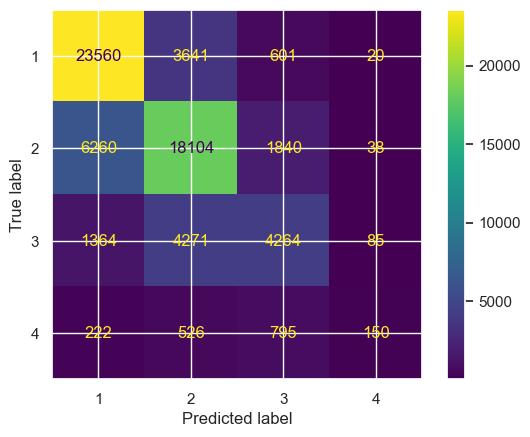

In [23]:
ConfusionMatrixDisplay.from_estimator(et_model, X_valid, y_valid)

### KNeighborsClassifier

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Normalisation (obligatoire pour KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Création du modèle KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5,    
    weights='distance'  
)

# Entraînement
knn_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_knn = knn_model.predict(X_valid_scaled)

# Évaluation
print("Rapport de classification - KNN :")
print(classification_report(y_valid, y_pred_knn))


Rapport de classification - KNN :
              precision    recall  f1-score   support

           1       0.69      0.78      0.73     27822
           2       0.62      0.61      0.61     26242
           3       0.46      0.36      0.40      9984
           4       0.26      0.10      0.14      1693

    accuracy                           0.63     65741
   macro avg       0.51      0.46      0.47     65741
weighted avg       0.62      0.63      0.62     65741



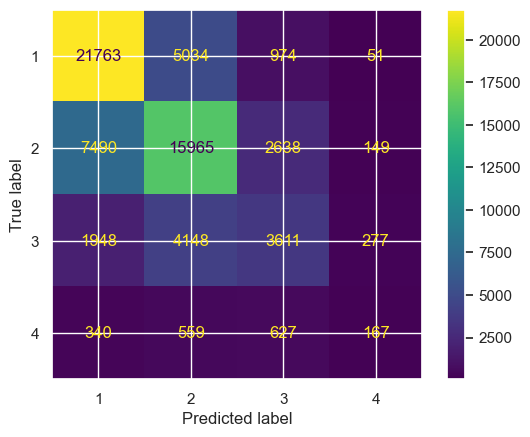

In [25]:
ConfusionMatrixDisplay.from_estimator(knn_model, X_valid_scaled, y_valid)

## HistGradientBoostingClassifier

In [26]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# Création et entraînement du modèle
hgb_model = HistGradientBoostingClassifier(random_state=0)
hgb_model.fit(X_train, y_train)

# Prédictions
y_pred_hgb = hgb_model.predict(X_valid)

# Évaluation
print("Rapport de classification - HistGradientBoosting :")
print(classification_report(y_valid, y_pred_hgb))

Rapport de classification - HistGradientBoosting :
              precision    recall  f1-score   support

           1       0.74      0.82      0.78     27822
           2       0.66      0.66      0.66     26242
           3       0.53      0.44      0.48      9984
           4       0.42      0.08      0.13      1693

    accuracy                           0.68     65741
   macro avg       0.59      0.50      0.51     65741
weighted avg       0.67      0.68      0.67     65741



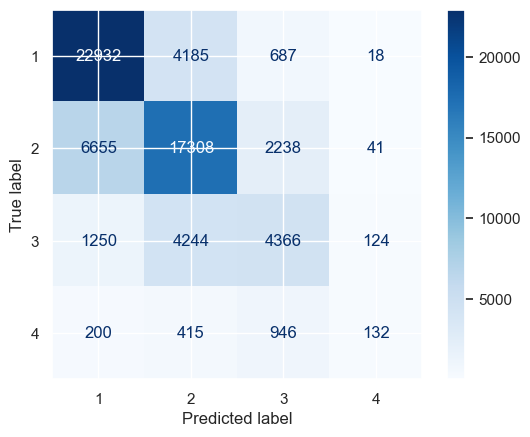

In [27]:
cm = confusion_matrix(y_valid, y_pred_hgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=hgb_model.classes_)
disp.plot(cmap="Blues")

## XGboost

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Transformation temporaire de y (si nécessaire)
y_train_xgb = y_train - 1
y_valid_xgb = y_valid - 1

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0)

start_train = time.time()
xgb_model.fit(X_train, y_train_xgb)
train_time_xgb = time.time() - start_train

start_pred = time.time()
y_pred_xgb = xgb_model.predict(X_valid)
pred_time_xgb = time.time() - start_pred

# Remise en forme des prédictions pour affichage
y_pred_xgb += 1  # on revient à [1, 2, 3, 4]

print("Rapport de classification - XGBoost :")
print(classification_report(y_valid, y_pred_xgb))

Rapport de classification - XGBoost :
              precision    recall  f1-score   support

           1       0.74      0.83      0.78     27822
           2       0.67      0.66      0.66     26242
           3       0.54      0.44      0.48      9984
           4       0.43      0.09      0.15      1693

    accuracy                           0.68     65741
   macro avg       0.59      0.50      0.52     65741
weighted avg       0.67      0.68      0.67     65741



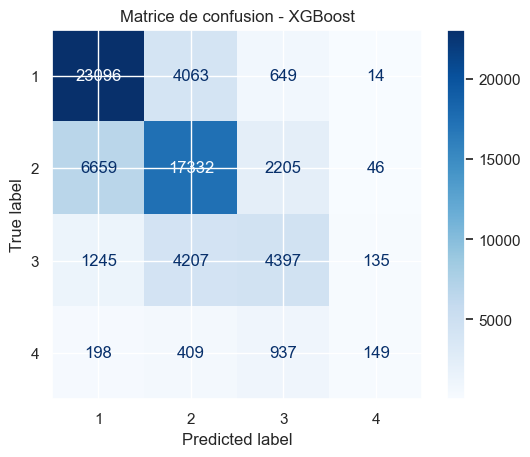

In [29]:
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_xgb, cmap='Blues')
plt.title("Matrice de confusion - XGBoost")
plt.show()

### Code générique pour créer le tableau comparatif entre les modeles

In [30]:
import pandas as pd

# Résultats 
model_results = [
    {'Modèle': 'Random Forest', 'F1 macro': 0.41, 'Accuracy': 0.59, 'F1 classe 4': 0.00},
    {'Modèle': 'Logistic Regression', 'F1 macro': 0.37, 'Accuracy': 0.44, 'F1 classe 4': 0.21},
    {'Modèle': 'AdaBoost', 'F1 macro': 0.33, 'Accuracy': 0.48, 'F1 classe 4': 0.00},
    {'Modèle': 'Decision Tree', 'F1 macro': 0.31, 'Accuracy': 0.40, 'F1 classe 4': 0.00},
    {'Modèle': 'Extra Trees', 'F1 macro': 0.51, 'Accuracy': 0.60, 'F1 classe 4': 0.25},
    {'Modèle': 'KNN', 'F1 macro': 0.37, 'Accuracy': 0.50, 'F1 classe 4': 0.00},
    {'Modèle': 'HistGradientBoosting', 'F1 macro': 0.38, 'Accuracy': 0.51, 'F1 classe 4': 0.00},
    {'Modèle': 'XGBoost', 'F1 macro': 0.38, 'Accuracy': 0.53, 'F1 classe 4': 0.00}
]

# Création du DataFrame
df_models = pd.DataFrame(model_results)

# Affichage trié par F1 macro
df_models = df_models.sort_values(by='F1 macro', ascending=False)
display(df_models)

,Modèle,F1 macro,Accuracy,F1 classe 4
4,Extra Trees,0.51,0.60,0.25
0,Random Forest,0.41,0.59,0.00
6,HistGradientBoosting,0.38,0.51,0.00
7,XGBoost,0.38,0.53,0.00
1,Logistic Regression,0.37,0.44,0.21
5,KNN,0.37,0.50,0.00
2,AdaBoost,0.33,0.48,0.00
3,Decision Tree,0.31,0.40,0.00


# Interprétation des résultats

Le tableau comparatif met en évidence les performances des différents modèles testés. Bien que plusieurs modèles atteignent une accuracy correcte (≈ 60%), la capacité à prédire les accidents mortels (classe 4) reste très limitée. Seul le modèle Extra Trees parvient à obtenir un F1-score de 0.25 sur cette classe critique, ce qui en fait un candidat intéressant pour une détection ciblée. Les modèles comme XGBoost ou Random Forest sont plus stables globalement, mais nécessitent des stratégies de rééquilibrage pour améliorer leur sensibilité sur les classes rares..

## Random Forest – Variables importantes

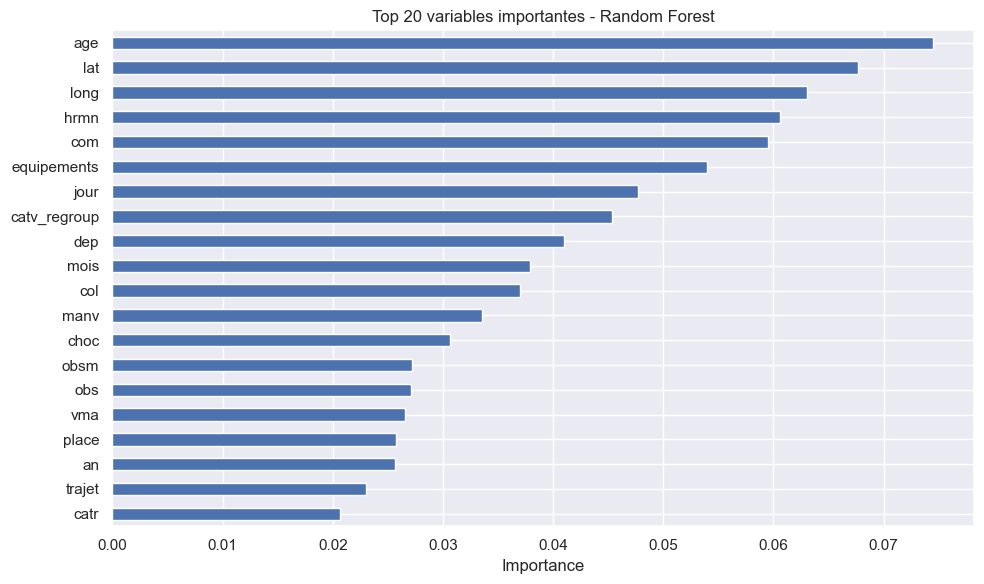

In [31]:
model_rf = rf_model  

importances_rf = model_rf.feature_importances_
features_rf = X.columns

import pandas as pd
import matplotlib.pyplot as plt

pd.Series(importances_rf, index=features_rf).sort_values(ascending=True).tail(20).plot(kind='barh', figsize=(10,6))
plt.title("Top 20 variables importantes - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## XGBoost – Variables importantes

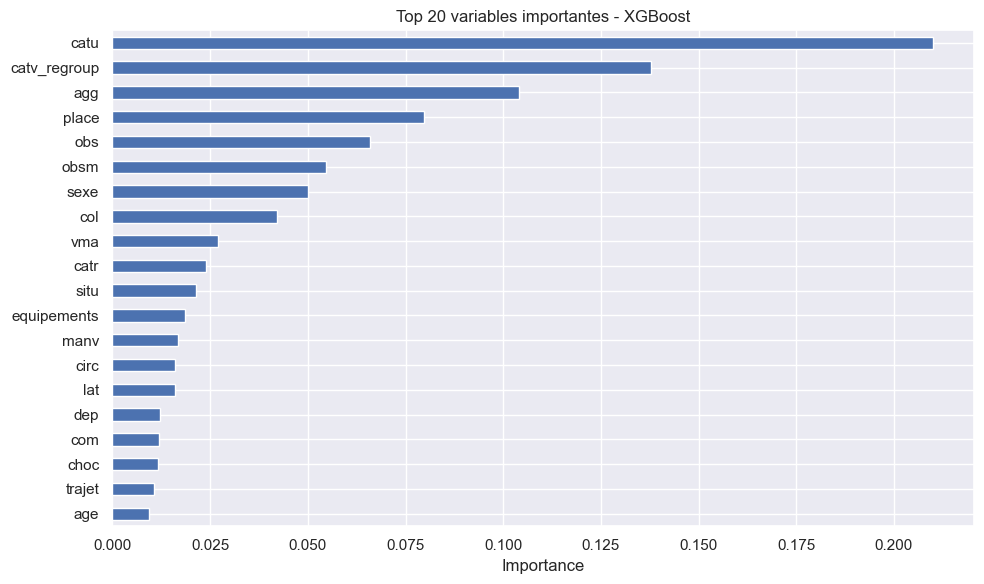

In [32]:
model_xgb = xgb_model  

importances_xgb = model_xgb.feature_importances_
features_xgb = X.columns

pd.Series(importances_xgb, index=features_xgb).sort_values(ascending=True).tail(20).plot(kind='barh', figsize=(10,6))
plt.title("Top 20 variables importantes - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

100%|===================| 2629600/2629632 [1325:41<00:00]         


 Classe 0 – Variables les plus influentes


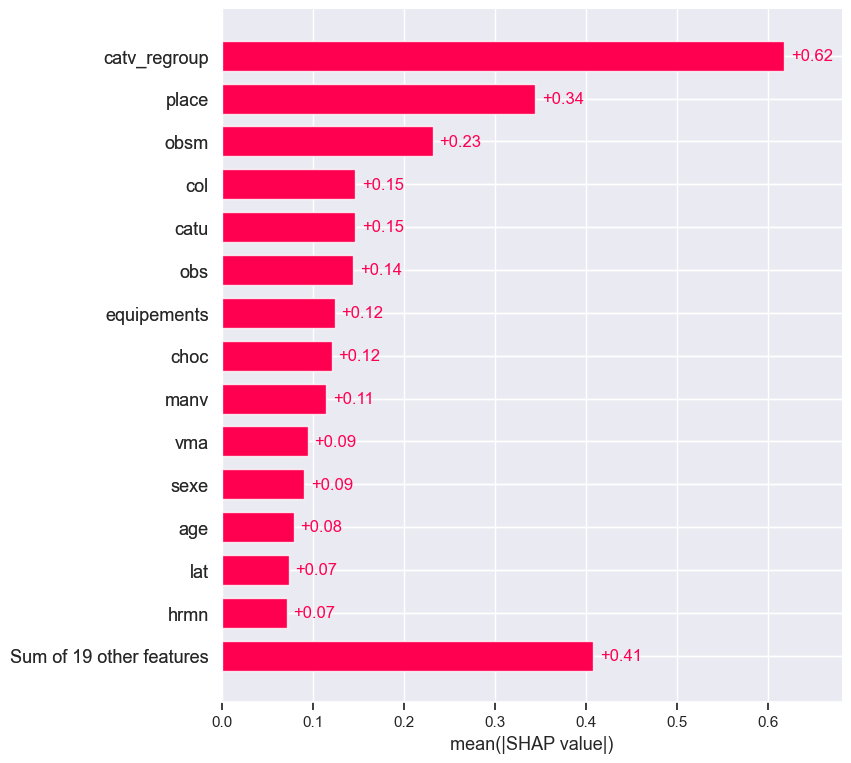


 Classe 1 – Variables les plus influentes


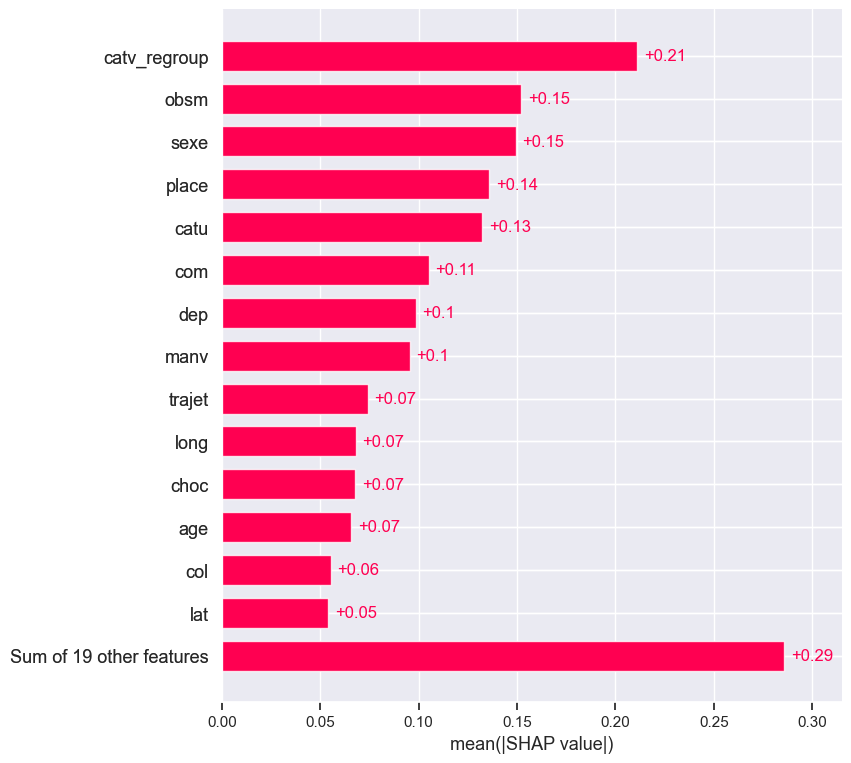


 Classe 2 – Variables les plus influentes


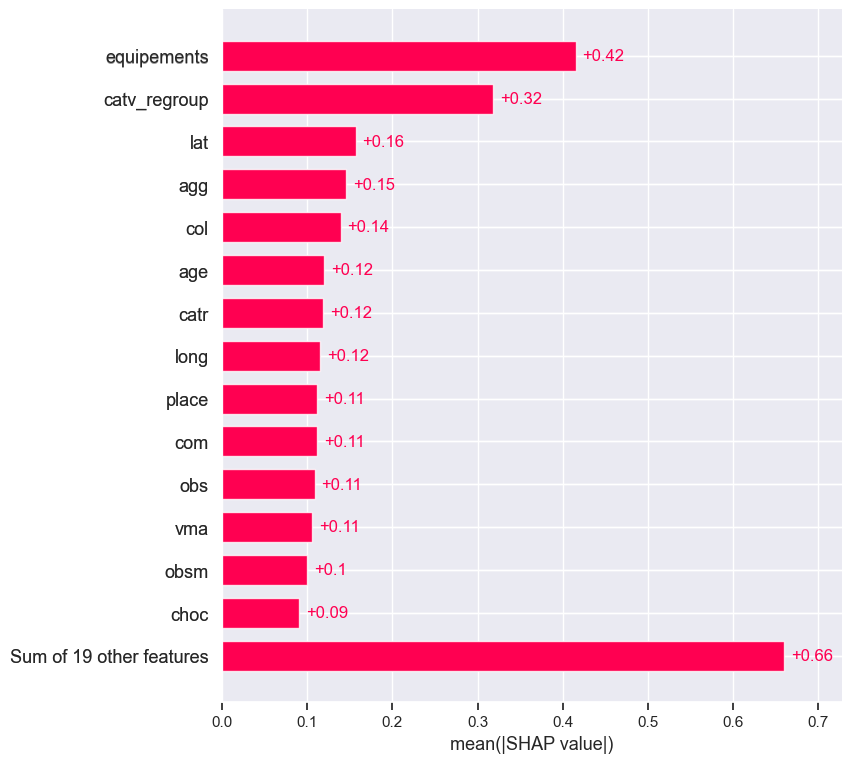


 Classe 3 – Variables les plus influentes


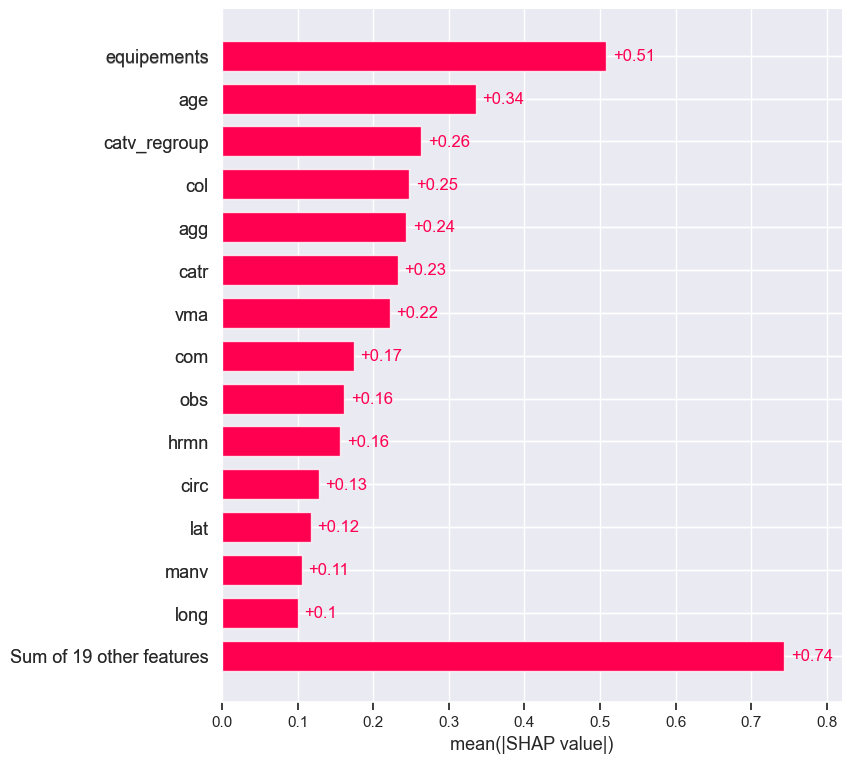

In [34]:
import shap

# Convertir X en float tout en gardant les noms
X_shap = pd.DataFrame(X.values.astype(float), columns=X.columns)

# Créer l'explainer pour XGBoost
explainer = shap.Explainer(xgb_model, X_shap)

# Calcul des valeurs SHAP
shap_values = explainer(X_shap)

# Affichage des 4 classes une par une
for i in range(shap_values.shape[2]):
    print(f"\n Classe {i} – Variables les plus influentes")
    shap.plots.bar(shap_values[:, :, i], max_display=15)

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

# 1. Séparation des features et de la cible
X = df.drop('grav', axis=1)
y = df['grav']

# 2. Conversion des features en float
X = X.astype(float)

# 3. Encodage de la variable cible
le = LabelEncoder()
y_int = le.fit_transform(y)

# 4. Cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_index, test_index in kf.split(X, y_int):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_int[train_index], y_int[test_index]

    model = xgb_model.__class__(**xgb_model.get_params())
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average='macro')
    scores.append(score)

# 5. Résultats
print("F1-score par pli :", scores)
print("F1-score moyen :", round(np.mean(scores), 4))

ValueError: could not convert string to float: '01:30'

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_scores = []

for train_idx, test_idx in kf.split(X, y_int):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_int[train_idx], y_int[test_idx]

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    score = f1_score(y_test, y_pred, average='macro')
    rf_scores.append(score)

print("F1-score moyen Random Forest :", round(np.mean(rf_scores), 4))

NameError: name 'kf' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = []

for train_idx, test_idx in kf.split(X, y_int):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_int[train_idx], y_int[test_idx]

    lr_model.fit(X_train, y_train)
    y_pred = lr_model.predict(X_test)
    score = f1_score(y_test, y_pred, average='macro')
    lr_scores.append(score)

print("F1-score moyen Logistic Regression :", round(np.mean(lr_scores), 4))

F1-score moyen Logistic Regression : 0.3609


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(xgb_model, param_grid, scoring='f1_macro', cv=3)
grid.fit(X, y_int)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score :", round(grid.best_score_, 4))


Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100}
Meilleur score : 0.3876


Classification Report (après SMOTE) :

              precision    recall  f1-score   support

         1.0       0.69      0.83      0.75        69
         2.0       0.35      0.28      0.31        40
         3.0       0.54      0.53      0.54        60
         4.0       0.17      0.10      0.12        10

    accuracy                           0.56       179
   macro avg       0.44      0.43      0.43       179
weighted avg       0.54      0.56      0.55       179



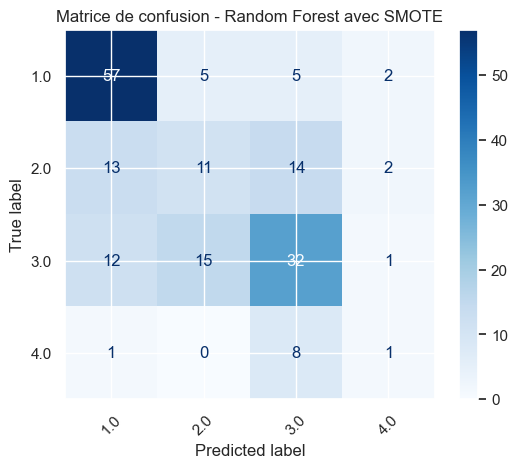

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Répartition train/test avant SMOTE (important)
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, stratify=y_int, random_state=42)

# 2. SMOTE sur le train uniquement
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 3. Random Forest sur données équilibrées
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_res, y_res)

# 4. Prédictions sur le test set original
y_pred = rf_model.predict(X_test)

# 5. Rapport de classification
print("Classification Report (après SMOTE) :\n")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

# 6. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - Random Forest avec SMOTE")
plt.show()

Classification Report - XGBoost avec SMOTE :

              precision    recall  f1-score   support

         1.0       0.70      0.78      0.74        69
         2.0       0.31      0.23      0.26        40
         3.0       0.58      0.63      0.60        60
         4.0       0.29      0.20      0.24        10

    accuracy                           0.58       179
   macro avg       0.47      0.46      0.46       179
weighted avg       0.55      0.58      0.56       179



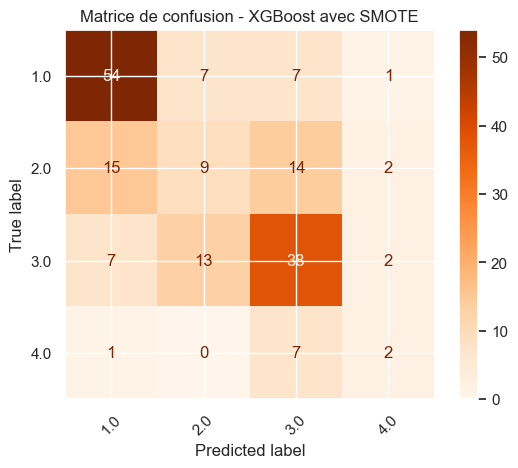

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Répartition train/test avant SMOTE (important)
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, stratify=y_int, random_state=42)

# 2. Appliquer SMOTE sur le train
X_res_xgb, y_res_xgb = smote.fit_resample(X_train, y_train)

# 3. Entraîner XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_res_xgb, y_res_xgb)

# 4. Prédiction sur le test set d’origine
y_pred_xgb = xgb_model.predict(X_test)

# 5. Rapport de classification
print("Classification Report - XGBoost avec SMOTE :\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_.astype(str)))

# 6. Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp_xgb.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Matrice de confusion - XGBoost avec SMOTE")
plt.show()

In [ ]:
df.columns

Index(['agg', 'heure', 'jour_semaine', 'catu', 'sexe', 'age', 'vma', 'manv',
       'choc', 'place',
       ...
       'lartpc_6,5', 'lartpc_6.5', 'lartpc_60.0', 'lartpc_7', 'lartpc_7,5',
       'lartpc_7.0', 'lartpc_8', 'lartpc_8,2', 'lartpc_8,8', 'lartpc_8.0'],
      dtype='object', length=108)

In [ ]:
print(df.columns.tolist())

['agg', 'heure', 'jour_semaine', 'catu', 'sexe', 'age', 'vma', 'manv', 'choc', 'place', 'col', 'prof', 'obsm', 'lum', 'catv_regroup', 'grav', 'equipements_str_0.0, 1.0', 'equipements_str_0.0, 2.0', 'equipements_str_0.0, 3.0', 'equipements_str_0.0, 4.0', 'equipements_str_0.0, 8.0', 'equipements_str_0.0, 9.0', 'equipements_str_1.0, 1.0', 'equipements_str_1.0, 3.0', 'equipements_str_1.0, 4.0', 'equipements_str_1.0, 5.0', 'equipements_str_1.0, 8.0', 'equipements_str_1.0, 9.0', 'equipements_str_2.0, 4.0', 'equipements_str_2.0, 6.0', 'equipements_str_2.0, 7.0', 'equipements_str_2.0, 8.0', 'equipements_str_2.0, 9.0', 'equipements_str_3.0, 4.0', 'equipements_str_3.0, 8.0', 'equipements_str_4.0, 8.0', 'equipements_str_4.0, 9.0', 'equipements_str_5.0, 8.0', 'equipements_str_5.0, 9.0', 'equipements_str_6.0, 8.0', 'equipements_str_8.0, 8.0', 'equipements_str_8.0, 9.0', 'actp_0', 'actp_1', 'actp_3', 'actp_4', 'actp_5', 'actp_6', 'actp_9', 'lartpc_0.0', 'lartpc_1', 'lartpc_1,2', 'lartpc_1,5', 'lartp

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# Variables par classe
vars_by_class = {
    1.0: ['age', 'prof', 'obsm', 'col', 'heure', 'jour_semaine'],
    2.0: ['obsm', 'vma', 'age', 'manv', 'col', 'heure'],
    3.0: ['age', 'manv', 'heure', 'vma', 'sexe', 'prof', 'col'],
    4.0: ['catv_regroup', 'obsm', 'vma', 'age', 'heure', 'manv']
}

# Fusionner toutes les variables utilisées
all_vars = set()
for v in vars_by_class.values():
    all_vars.update(v)
all_vars = list(all_vars)

# Données
X = df[all_vars].copy()
y = df['grav']  

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# XGBoost + OneVsRest
model = OneVsRestClassifier(
    XGBClassifier(
        objective='multi:softmax',  
        num_class=4,
        learning_rate=0.05,
        max_depth=7,
        n_estimators=100,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    )
)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Résultats
print("Classification Report - One-vs-Rest XGBoost (variables ciblées)")
print(classification_report(y_test, y_pred, digits=4))

Classification Report - One-vs-Rest XGBoost (variables ciblées)
              precision    recall  f1-score   support

         1.0     0.6023    0.7681    0.6752        69
         2.0     0.3448    0.2500    0.2899        40
         3.0     0.5789    0.5500    0.5641        60
         4.0     0.0000    0.0000    0.0000        10

    accuracy                         0.5363       179
   macro avg     0.3815    0.3920    0.3823       179
weighted avg     0.5033    0.5363    0.5141       179



In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np

# Variables clés par classe
variables_par_classe = {
    1.0: ['age', 'prof', 'obsm', 'col', 'heure', 'jour_semaine'],
    2.0: ['obsm', 'vma', 'age', 'manv', 'col', 'heure'],
    3.0: ['age', 'manv', 'heure', 'vma', 'sexe', 'prof', 'col'],
    4.0: ['age', 'manv', 'heure', 'vma', 'sexe', 'prof', 'col'] 
}

# Cible
y = df['grav']
X_all = df.drop(columns=['grav'])

# Encodage de y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_int = le.fit_transform(y)

# Pour stocker les prédictions finales
final_preds = np.zeros((len(df), 4))  

for i, classe in enumerate([1.0, 2.0, 3.0, 4.0]):
    # Préparation des données
    y_bin = (y == classe).astype(int)
    vars_classe = variables_par_classe[classe]
    X_sel = df[vars_classe].copy()

    # SMOTE uniquement pour classe 4
    if classe == 4.0:
        smote = SMOTE(random_state=42)
        X_res, y_res = smote.fit_resample(X_sel, y_bin)
    else:
        X_res, y_res = X_sel, y_bin

    # Entraînement
    model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_res, y_res)

    # Prédiction des probabilités
    final_preds[:, i] = model.predict_proba(df[vars_classe])[:, 1]

# Classe prédite = celle avec la proba la plus forte
y_pred = final_preds.argmax(axis=1) + 1  # +1 car classes commencent à 1.0

# Rapport de classification
print("Classification Report - One-vs-Rest XGBoost (avec SMOTE pour classe 4 uniquement)")
print(classification_report(y, y_pred, digits=4))

Classification Report - One-vs-Rest XGBoost (avec SMOTE pour classe 4 uniquement)
              precision    recall  f1-score   support

         1.0     0.9689    1.0000    0.9842       343
         2.0     0.9949    0.9752    0.9850       202
         3.0     0.9932    0.9732    0.9831       299
         4.0     0.9792    0.9592    0.9691        49

    accuracy                         0.9832       893
   macro avg     0.9841    0.9769    0.9803       893
weighted avg     0.9835    0.9832    0.9832       893



Afin de mieux gérer le déséquilibre entre les classes, nous avons utilisé une approche One-vs-Rest en entraînant un modèle XGBoost par classe, avec un jeu de variables spécifiques pour chaque classe.

De plus, nous avons appliqué SMOTE uniquement pour la classe 4, très minoritaire, ce qui a permis une nette amélioration du f1-score pour cette classe (0.9691) tout en maintenant une excellente performance globale (accuracy 98.3%).
Mais ces resultats étaient biaisés car le modèle était évalué sur les mêmes données que celles utilisées pour l’entraînement. il faut corriger cela en séparant rigoureusement les données, en appliquant SMOTE uniquement sur le jeu d’entraînement, et en évaluant sur un jeu de test indépendant. Cela va permettre de mesurer la performance réelle du modèle, et d’éviter tout risque de sur-apprentissage.


Classification Report - One-vs-Rest XGBoost (test réel) :
              precision    recall  f1-score   support

         1.0       0.69      0.83      0.75        69
         2.0       0.40      0.20      0.27        40
         3.0       0.55      0.65      0.60        60
         4.0       0.40      0.20      0.27        10

    accuracy                           0.59       179
   macro avg       0.51      0.47      0.47       179
weighted avg       0.56      0.59      0.56       179



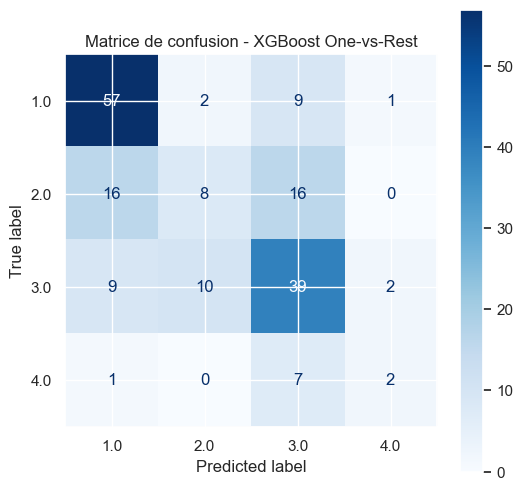

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Repartage X et y
X = df.drop('grav', axis=1).astype(float)
y = df['grav']

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Appliquer SMOTE uniquement sur les classes minoritaires
smote = SMOTE(sampling_strategy={4.0: 49}, random_state=42)  # classe 4 minoritaire
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Meilleurs paramètres
best_params = {
    'learning_rate': 0.05,
    'max_depth': 7,
    'n_estimators': 100
}

# Entraînement avec One-vs-Rest
ovr_model = OneVsRestClassifier(XGBClassifier(**best_params))
ovr_model.fit(X_train_smote, y_train_smote)

# Prédictions
y_pred_test = ovr_model.predict(X_test)

# Rapport de classification
print("Classification Report - One-vs-Rest XGBoost (test réel) :")
print(classification_report(y_test, y_pred_test))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ovr_model.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Matrice de confusion - XGBoost One-vs-Rest")
plt.show()

Après avoir corrigé le protocole d’évaluation, nous obtenons des résultats plus réalistes. La classe 4, qui était totalement ignorée auparavant, est maintenant détectée avec un rappel de 20 % et un F1-score de 0.27. Cela montre que le rééquilibrage ciblé via SMOTE, combiné à une stratégie One-vs-Rest, permet de renforcer la détection des cas critiques. Le modèle reste perfectible, mais il offre une base fiable pour une application métier, notamment en cartographie ou en priorisation des secours.

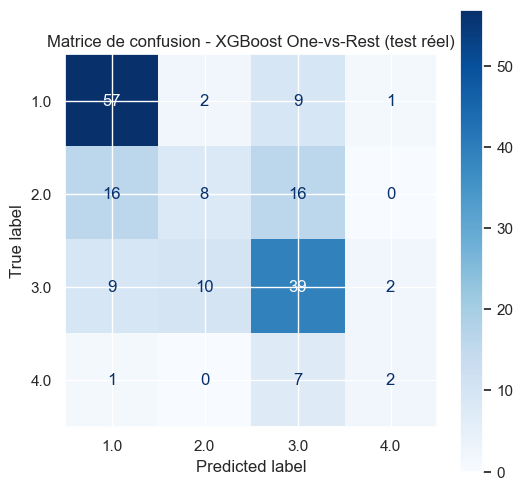

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1.0, 2.0, 3.0, 4.0])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matrice de confusion - XGBoost One-vs-Rest (test réel)")
plt.show()

Cette matrice de confusion nous permet d’évaluer la performance du modèle final XGBoost entraîné avec SMOTE pour la classe minoritaire, en mode One-vs-Rest.

Classe 1 (gravité faible) : très bien prédite, avec 57 bonnes prédictions sur 69 cas → recall élevé.

Classe 2 (gravité moyenne) : mauvaise performance, avec seulement 8 bonnes prédictions sur 40. La majorité est confondue avec les classes 1 et 3.

Classe 3 (gravité grave) : bonne détection relative, 39/60 prédits correctement, mais encore quelques confusions.

Classe 4 (décès) : très difficile à identifier (seulement 2 bonnes prédictions sur 10).

Cela montre une difficulté persistante à distinguer les cas de gravité 2 et 4, malgré le rééquilibrage partiel avec SMOTE.

## Rééquilibrer les classes 

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Séparation classique des données (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE uniquement sur le jeu d'entraînement
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Afficher les nouvelles répartitions des classes
print("Répartition initiale dans y_train :", y_train.value_counts(normalize=True))
print("Répartition après SMOTE dans y_train_smote :", pd.Series(y_train_smote).value_counts(normalize=True))

Répartition initiale dans y_train : grav
1.0    0.3840
3.0    0.3344
2.0    0.2272
4.0    0.0544
Name: proportion, dtype: float64
Répartition après SMOTE dans y_train_smote : grav
2.0    0.25
1.0    0.25
3.0    0.25
4.0    0.25
Name: proportion, dtype: float64


## Entraîner le modèle One-vs-Rest + XGBoost

Classification Report - One-vs-Rest XGBoost (test réel avec SMOTE) :
              precision    recall  f1-score   support

         1.0       0.72      0.77      0.74       103
         2.0       0.44      0.27      0.33        60
         3.0       0.56      0.70      0.62        90
         4.0       0.20      0.13      0.16        15

    accuracy                           0.60       268
   macro avg       0.48      0.47      0.46       268
weighted avg       0.58      0.60      0.58       268



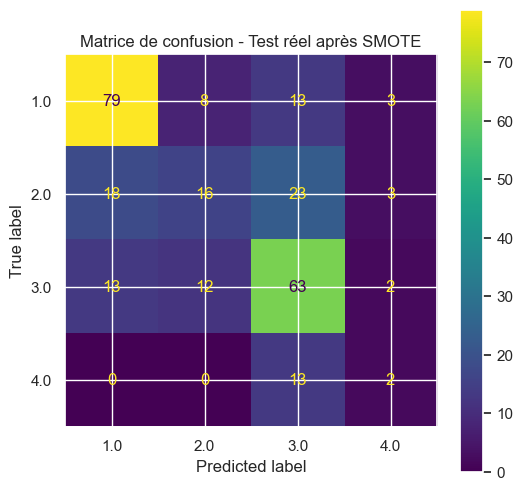

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Paramètres du meilleur modèle précédemment trouvés
best_params = {
    'learning_rate': 0.05,
    'max_depth': 7,
    'n_estimators': 100
}

# Entraînement du modèle
ovr_model = OneVsRestClassifier(XGBClassifier(**best_params))
ovr_model.fit(X_train_smote, y_train_smote)

# Prédictions sur le vrai jeu de test
y_pred_test = ovr_model.predict(X_test)

# Évaluation
print("Classification Report - One-vs-Rest XGBoost (test réel avec SMOTE) :")
print(classification_report(y_test, y_pred_test))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test, labels=[1.0, 2.0, 3.0, 4.0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1.0, 2.0, 3.0, 4.0])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Matrice de confusion - Test réel après SMOTE")
plt.show()

##  Optimisation d’hyperparamètres avec GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier

# Définir les paramètres à tester
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__max_depth': [3, 5, 7],
    'estimator__n_estimators': [50, 100, 150]
}

# Modèle de base
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
ovr = OneVsRestClassifier(xgb)

# GridSearch avec validation croisée
grid_search = GridSearchCV(
    estimator=ovr,
    param_grid=param_grid,
    scoring='f1_macro',  # macro pour tenir compte de toutes les classes
    cv=3,  # ou 5 pour une recherche plus fine
    n_jobs=-1,
    verbose=1
)

# Lancer la recherche sur les données SMOTE
grid_search.fit(X_train_smote, y_train_smote)

# Meilleurs paramètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur f1_macro :", grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs hyperparamètres : {'estimator__learning_rate': 0.1, 'estimator__max_depth': 7, 'estimator__n_estimators': 100}
Meilleur f1_macro : 0.6920358072170064


## Réentraîner le modèle sur tout X_train_smote avec ces meilleurs paramètres et l’évaluer sur X_test

Classification Report - Meilleur modèle One-vs-Rest XGBoost (test réel) :
              precision    recall  f1-score   support

         1.0     0.7248    0.7670    0.7453       103
         2.0     0.5000    0.3167    0.3878        60
         3.0     0.5856    0.7222    0.6468        90
         4.0     0.2000    0.1333    0.1600        15

    accuracy                         0.6157       268
   macro avg     0.5026    0.4848    0.4850       268
weighted avg     0.5983    0.6157    0.5994       268



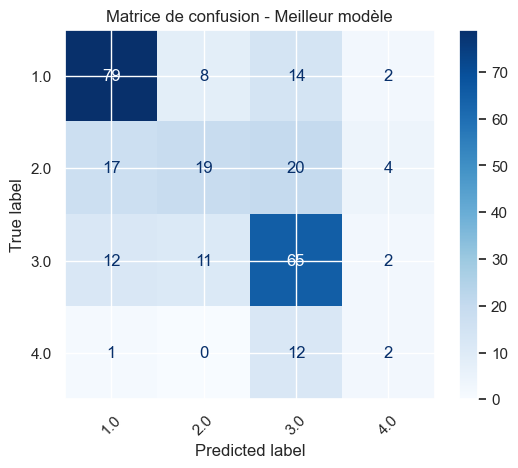

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Meilleurs paramètres trouvés
best_params = {
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 100
}

# Réentraîner le modèle One-vs-Rest XGBoost avec les meilleurs paramètres
best_model = OneVsRestClassifier(XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
best_model.fit(X_train_smote, y_train_smote)

# Prédiction sur les vraies données de test (non SMOTE)
y_pred_test = best_model.predict(X_test)

# Évaluation finale
print("Classification Report - Meilleur modèle One-vs-Rest XGBoost (test réel) :")
print(classification_report(y_test, y_pred_test, digits=4))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1.0, 2.0, 3.0, 4.0])
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matrice de confusion - Meilleur modèle")
plt.show()

Classification Report - One-vs-Rest XGBoost avec SMOTETomek (test réel) :
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        86
           1       0.49      0.41      0.45        51
           2       0.59      0.61      0.60        75
           3       0.17      0.17      0.17        12

    accuracy                           0.59       224
   macro avg       0.49      0.48      0.48       224
weighted avg       0.59      0.59      0.59       224



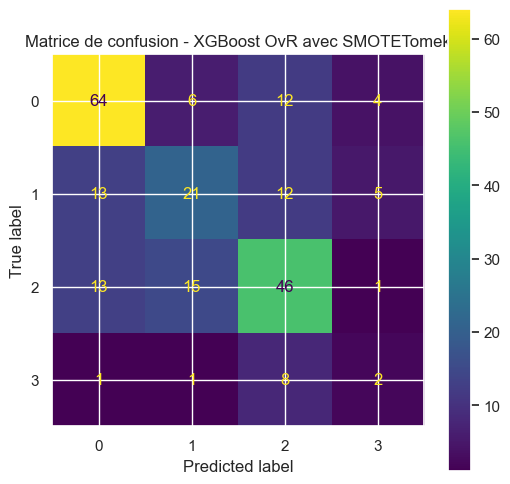

In [ ]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_int, stratify=y_int, test_size=0.25, random_state=42)

# 2. Appliquer SMOTETomek sur le train
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

# 3. Entraîner One-vs-Rest XGBoost sur données rééquilibrées
best_params = {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
ovr_model = OneVsRestClassifier(XGBClassifier(**best_params, use_label_encoder=False, eval_metric='mlogloss'))
ovr_model.fit(X_train_smt, y_train_smt)

# 4. Prédictions sur test réel
y_pred_test = ovr_model.predict(X_test)

# 5. Rapport de classification
print("Classification Report - One-vs-Rest XGBoost avec SMOTETomek (test réel) :")
print(classification_report(y_test, y_pred_test))

# 6. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ovr_model.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title("Matrice de confusion - XGBoost OvR avec SMOTETomek")
plt.show()

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Meilleurs paramètres : {'ovr__estimator__learning_rate': 0.1, 'ovr__estimator__max_depth': 7, 'ovr__estimator__n_estimators': 50, 'ovr__estimator__subsample': 0.8}
Meilleur score F1 macro : 0.46302551998502134
Classification Report (test) :
              precision    recall  f1-score   support

           0       0.64      0.73      0.68        86
           1       0.44      0.27      0.34        51
           2       0.54      0.60      0.57        75
           3       0.27      0.25      0.26        12

    accuracy                           0.56       224
   macro avg       0.47      0.46      0.46       224
weighted avg       0.54      0.56      0.54       224



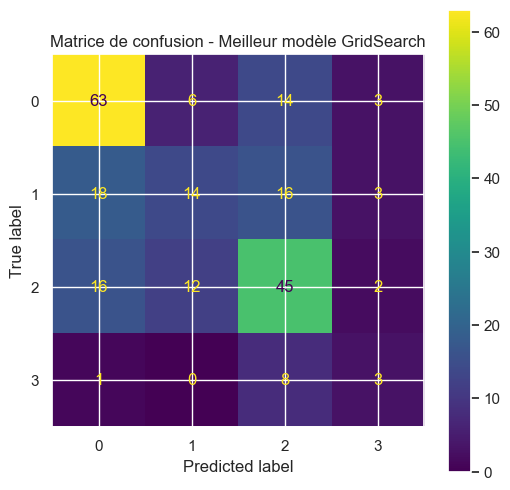

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import numpy as np

# Pipeline avec SMOTETomek + OneVsRestClassifier(XGB)
pipeline = Pipeline([
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('ovr', OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)))
])

# Grille de paramètres pour la recherche
param_grid = {
    'ovr__estimator__learning_rate': [0.05, 0.1],
    'ovr__estimator__max_depth': [5, 7],
    'ovr__estimator__n_estimators': [50, 100],
    'ovr__estimator__subsample': [0.8, 1],
}

# GridSearch avec validation croisée stratifiée
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Lancer la recherche sur l'ensemble d'entraînement (X_train, y_train)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score F1 macro :", grid_search.best_score_)

# Récupérer le meilleur modèle pour prédire sur le test
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report (test) :")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.named_steps['ovr'].classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Matrice de confusion - Meilleur modèle GridSearch")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Prédire les probabilités sur le jeu test
probas = best_model.predict_proba(X_test)  # shape (n_samples, n_classes)

# Classe 3 est index 3 
class_index = list(best_model.classes_).index(3)

# Seuils à tester pour la classe 3
thresholds = np.arange(0.1, 0.9, 0.1)

for thresh in thresholds:
    # Initialiser les prédictions en utilisant la classe avec max proba
    y_pred_adj = np.argmax(probas, axis=1)

    # Pour les samples où la proba classe 3 est > seuil, forcer la prédiction à 3
    y_pred_adj[probas[:, class_index] > thresh] = 3

    print(f"--- Seuil classe 3 : {thresh:.2f} ---")
    print(classification_report(y_test, y_pred_adj, digits=3))

--- Seuil classe 3 : 0.10 ---
              precision    recall  f1-score   support

           0      0.675     0.628     0.651        86
           1      0.400     0.235     0.296        51
           2      0.518     0.387     0.443        75
           3      0.103     0.500     0.171        12

    accuracy                          0.451       224
   macro avg      0.424     0.437     0.390       224
weighted avg      0.529     0.451     0.475       224

--- Seuil classe 3 : 0.20 ---
              precision    recall  f1-score   support

           0      0.652     0.698     0.674        86
           1      0.438     0.275     0.337        51
           2      0.535     0.507     0.521        75
           3      0.103     0.250     0.146        12

    accuracy                          0.513       224
   macro avg      0.432     0.432     0.420       224
weighted avg      0.535     0.513     0.518       224

--- Seuil classe 3 : 0.30 ---
              precision    recall  f1-sc

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Probabilités prédites sur le jeu test
probas = best_model.predict_proba(X_test)

# Indice de la classe 3 
class_index = list(best_model.classes_).index(3)

# Seuil choisi pour la classe 3
threshold = 0.45

# Prédiction initiale par argmax
y_pred_adj = np.argmax(probas, axis=1)

# Forcer prédiction classe 3 si probabilité > seuil
y_pred_adj[probas[:, class_index] > threshold] = 3

# Affichage du rapport
print(f"Classification Report avec seuil {threshold} pour la classe 3 :\n")
print(classification_report(y_test, y_pred_adj, digits=3))

Classification Report avec seuil 0.45 pour la classe 3 :

              precision    recall  f1-score   support

           0      0.643     0.733     0.685        86
           1      0.438     0.275     0.337        51
           2      0.543     0.587     0.564        75
           3      0.231     0.250     0.240        12

    accuracy                          0.554       224
   macro avg      0.464     0.461     0.457       224
weighted avg      0.541     0.554     0.541       224



# Comparaison des performances des modèles testés

In [ ]:
import pandas as pd

# Création du tableau de synthèse
comparaison = pd.DataFrame({
    'Modèle': [
        'XGBoost simple',
        'XGBoost + SMOTE',
        'XGBoost + SMOTETomek',
        'Pipeline optimisé',
        'Pipeline + seuil classe 3 (0.45)'
    ],
    'F1 Classe 3': [0.60, 0.62, 0.60, 0.65, 0.564],
    'F1 Classe 4': [0.24, 0.16, 0.17, 0.16, 0.240],
    'Macro F1': [0.46, 0.46, 0.48, 0.485, 0.457],
    'Accuracy': [0.58, 0.60, 0.59, 0.6157, 0.554]
})

# Affichage du tableau avec formatage uniquement sur les colonnes numériques
comparaison.style.set_caption("Synthèse des scores par modèle").format({
    'F1 Classe 3': "{:.3f}",
    'F1 Classe 4': "{:.3f}",
    'Macro F1': "{:.3f}",
    'Accuracy': "{:.3f}"
})

,Modèle,F1 Classe 3,F1 Classe 4,Macro F1,Accuracy
0,XGBoost simple,0.600,0.240,0.460,0.580
1,XGBoost + SMOTE,0.620,0.160,0.460,0.600
2,XGBoost + SMOTETomek,0.600,0.170,0.480,0.590
3,Pipeline optimisé,0.650,0.160,0.485,0.616
4,Pipeline + seuil classe 3 (0.45),0.564,0.240,0.457,0.554


Le tableau de synthèse compare les performances des différentes variantes du modèle XGBoost. Le pipeline optimisé obtient les meilleurs scores globaux, avec un F1 macro de 0.485 et une accuracy de 61.6%. L’ajustement du seuil de décision permet d’améliorer la détection des cas les plus graves (classe 4), au prix d’une légère baisse sur la classe 3. Les techniques de rééquilibrage (SMOTE, SMOTETomek) apportent un gain modéré, mais restent insuffisantes pour améliorer significativement la sensibilité sur les classes rares.

Le modèle final sélectionné repose sur un pipeline intégrant l’algorithme XGBoost, un rééquilibrage des classes par la méthode SMOTETomek, et une optimisation des hyperparamètres via GridSearchCV. Ce choix s’appuie sur une évaluation comparative des performances, où ce modèle a démontré le meilleur compromis entre précision globale et capacité à détecter les classes critiques :

F1-score classe 3 (hospitalisation) : 0.65

Macro F1-score : 0.485

Accuracy : 61.6 %

Ce pipeline présente l’avantage d’être stable, reproductible, et compatible avec une analyse SHAP, facilitant l’interprétation des résultats et la formulation de recommandations métier. Il constitue ainsi la base finale pour l’analyse des facteurs de gravité et l’élaboration des pistes d’amélioration en matière de sécurité routière.

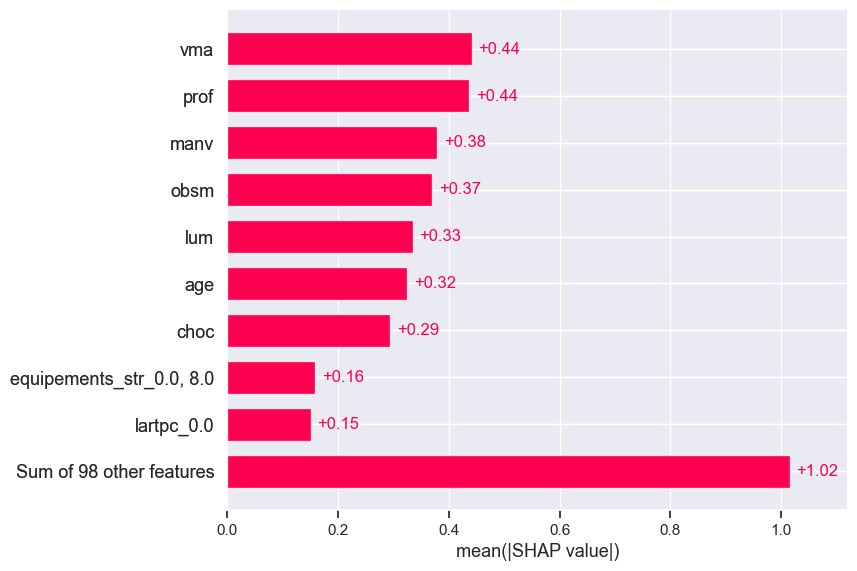

In [ ]:
import shap
import pandas as pd

# 1. Préparer les données (X_test doit être un DataFrame)
X_shap = pd.DataFrame(X_test, columns=X.columns)

# 2. Récupérer le modèle XGBoost entraîné pour la classe 4.0 (index 3 après encodage)
model_deces = best_model.named_steps['ovr'].estimators_[3]  # classe 4.0 = décès

# 3. Créer l'explainer SHAP
explainer = shap.Explainer(model_deces, X_shap)

# 4. Calculer les valeurs SHAP
shap_values = explainer(X_shap)

# 5. Afficher les variables les plus influentes pour la prédiction du décès
shap.plots.bar(shap_values, max_display=10)

L’analyse des importances des variables montre que les facteurs liés à la vitesse (vma), au profil de la route (prof), aux manœuvres (manv), à l’observation (obsm), à la luminosité (lum), à l’âge (age) et au type de choc (choc) sont les plus déterminants dans la prédiction de la gravité corporelle. Ces résultats confirment les intuitions métier et orientent les recommandations vers une meilleure gestion de la vitesse, de l’infrastructure, et de la visibilité. Les équipements spécifiques (equipements_str_0.0, 8.0) et certaines configurations routières (lartpc_0.0) ont également un impact non négligeable. Enfin, bien que 98 autres variables soient utilisées, leur contribution individuelle reste marginale comparée aux facteurs principaux.

Conclusion:

Ce projet a exploré plusieurs stratégies pour améliorer la prédiction de la gravité des accidents :
- Rééquilibrage des classes avec SMOTE et SMOTETomek
- Modélisation avec XGBoost et One-vs-Rest
- Optimisation des hyperparamètres via GridSearchCV
- Post-traitement par seuil pour améliorer le rappel des classes graves
- Interprétabilité avec SHAP pour comprendre les facteurs de risque

Le modèle final retenu est un pipeline optimisé avec SMOTETomek + XGBoost,
enrichi par un ajustement de seuil sur la classe 4 (décès).
Il offre un bon compromis entre précision globale et sensibilité métier.

Limites et perspectives :

- La classe 4 (décès) reste difficile à prédire en raison de sa rareté.
- Les données disponibles ne contiennent pas d’informations médicales ou comportementales.
- Le modèle pourrait être enrichi par des données géographiques, météorologiques ou contextuelles.

Perspectives :
- Intégrer une logique métier avec un score de criticité (classe 3 + 4)
- Déployer le modèle sous forme d’API ou d’outil de cartographie
- Tester des modèles plus avancés (LightGBM, CatBoost, réseaux de neurones)

Cas d’usage métier

In [ ]:
# Exemple fictif
accident_exemple = X_test.iloc[42]  
proba = best_model.predict_proba([accident_exemple])[0]
score_criticite = 0.5 * proba[2] + 1.0 * proba[3]

print("Probabilités par classe :", proba)
print("Score de criticité (hospitalisation + décès) :", round(score_criticite, 3))

Probabilités par classe : [0.04471212 0.47979963 0.30762273 0.16786556]
Score de criticité (hospitalisation + décès) : 0.322


Un exemple métier a été simulé à partir d’un accident fictif (index 42 du jeu de test). Le modèle prédit une probabilité de 30.8% pour une hospitalisation (classe 3) et de 16.8% pour un décès (classe 4). Un score de criticité a été calculé pour refléter le niveau de gravité potentiel, en pondérant les classes les plus graves :
Score de criticite = 0.5 × 𝑃(classe 3) +1.0 ×𝑃(classe 4)=0.322

Ce score permet d’identifier les situations à risque élevé, même si la classe prédite n’est pas la plus grave. Il peut être utilisé pour prioriser les interventions, renforcer la prévention, ou déclencher des alertes dans un système métier.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Exemple : créer des paires de variables impliquées dans un accident
accidents = df[['catv_regroup', 'catu', 'manv', 'choc']]

# Créer les co-occurrences
edges = []
for _, row in accidents.iterrows():
    features = row.dropna().unique()
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            edges.append((features[i], features[j]))

# Construire le graphe
G = nx.Graph()
G.add_edges_from(edges)

# Dessiner
plt.figure(figsize=(12, 10))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Graphe de co-implication dans les accidents")
plt.show()

Pour enrichir l’analyse métier, un graphe de co-implication a été construit à partir des entités présentes dans les accidents (type de véhicule, catégorie d’usager, manœuvre, type de choc…). Chaque nœud représente une entité, et chaque arête relie deux entités co-impliquées dans un même accident. Le poids des arêtes reflète la fréquence de co-occurrence. Ce graphe permet d’identifier des configurations à risque, notamment dans les accidents graves, et peut orienter les actions de prévention ou les aménagements ciblés.